In [3]:
#Task 1 BFS AND DFS ON TREE
from collections import deque

# Tree Node
class Node:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

# Create simple tree
#        A
#       / \
#      B   C
#     / \   \
#    D   E   F

root = Node("A")
root.left = Node("B")
root.right = Node("C")
root.left.left = Node("D")
root.left.right = Node("E")
root.right.right = Node("F")

# BFS on Tree
def bfs_tree(root):
    queue = deque([root])

    print("BFS Traversal:")
    while queue:
        node = queue.popleft()
        print(node.value, end=" ")

        if node.left:
            queue.append(node.left)
        if node.right:
            queue.append(node.right)

# DFS on Tree (Preorder)
def dfs_tree(root):
    if root:
        print(root.value, end=" ")
        dfs_tree(root.left)
        dfs_tree(root.right)

# Run
bfs_tree(root)
print("\nDFS Traversal:")
dfs_tree(root)

BFS Traversal:
A B C D E F 
DFS Traversal:
A B D E C F 

In [4]:
#Task 1 BFS AND DFS ON GRAPH
from collections import deque

# Graph (Adjacency List)
graph = {
    "A": ["B", "C"],
    "B": ["D", "E"],
    "C": ["F"],
    "D": [],
    "E": [],
    "F": []
}

# BFS on Graph
def bfs_graph(graph, start):
    visited = set()
    queue = deque([start])

    print("BFS Graph:")
    while queue:
        node = queue.popleft()

        if node not in visited:
            print(node, end=" ")
            visited.add(node)

            for neighbor in graph[node]:
                queue.append(neighbor)

# DFS on Graph
def dfs_graph(graph, node, visited=None):
    if visited is None:
        visited = set()

    if node not in visited:
        print(node, end=" ")
        visited.add(node)

        for neighbor in graph[node]:
            dfs_graph(graph, neighbor, visited)

# Run
bfs_graph(graph, "A")
print("\nDFS Graph:")
dfs_graph(graph, "A")

BFS Graph:
A B C D E F 
DFS Graph:
A B D E C F 

Processing size: 1000
Processing size: 40000
Processing size: 80000
Processing size: 200000
Processing size: 1000000

Final Table:

   Tree Size  BFS Time  DFS Time
0       1000  0.000113  0.000068
1      40000  0.008940  0.002962
2      80000  0.020260  0.006941
3     200000  0.033428  0.031389
4    1000000  0.303750  0.318135


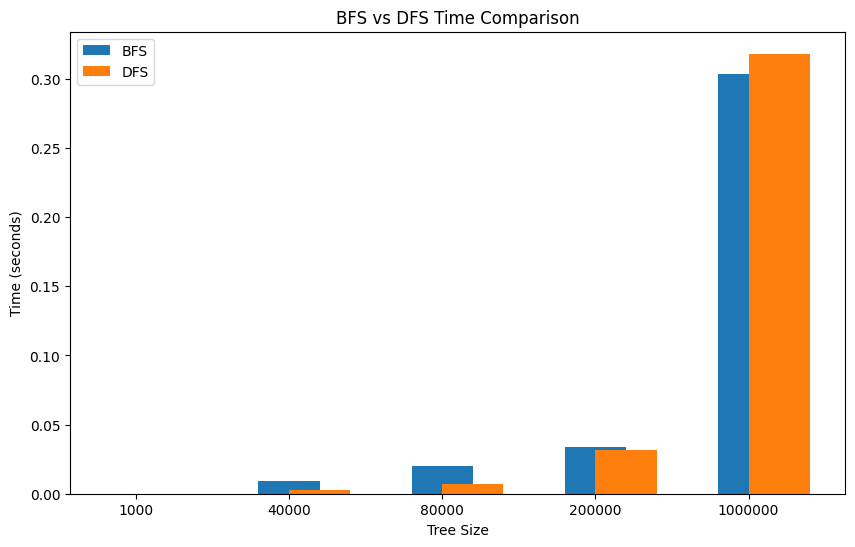

In [1]:
#TASK 2
import random
import time
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Tree Node Definition
# -----------------------------
class Node:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

# -----------------------------
# Step 2: Build Binary Tree
# -----------------------------
def build_tree(values):
    if not values:
        return None

    nodes = [Node(v) for v in values]

    for i in range(len(values)):
        if 2*i + 1 < len(values):
            nodes[i].left = nodes[2*i + 1]
        if 2*i + 2 < len(values):
            nodes[i].right = nodes[2*i + 2]

    return nodes[0]

# -----------------------------
# Step 3: BFS Search
# -----------------------------
def bfs(root, goal):
    queue = deque([root])

    while queue:
        node = queue.popleft()

        if node.value == goal:
            return True

        if node.left:
            queue.append(node.left)
        if node.right:
            queue.append(node.right)

    return False

# -----------------------------
# Step 4: DFS Search
# -----------------------------
def dfs(root, goal):
    stack = [root]

    while stack:
        node = stack.pop()

        if node.value == goal:
            return True

        if node.right:
            stack.append(node.right)
        if node.left:
            stack.append(node.left)

    return False

# -----------------------------
# Step 5: Main Execution
# -----------------------------
sizes = [1000, 40000, 80000, 200000, 1000000]

results = []

for size in sizes:
    print(f"Processing size: {size}")

    # Generate unique random numbers
    data = random.sample(range(size * 10), size)

    # Build tree
    root = build_tree(data)

    # Define goal
    goal = data[len(data) - 220]

    # BFS timing
    start = time.time()
    bfs(root, goal)
    bfs_time = time.time() - start

    # DFS timing
    start = time.time()
    dfs(root, goal)
    dfs_time = time.time() - start

    results.append([size, bfs_time, dfs_time])

# -----------------------------
# Step 6: DataFrame (TABLE)
# -----------------------------
df = pd.DataFrame(results, columns=["Tree Size", "BFS Time", "DFS Time"])
print("\nFinal Table:\n")
print(df)

# -----------------------------
# Step 7: Bar Chart
# -----------------------------
plt.figure(figsize=(10,6))

x = range(len(sizes))

plt.bar(x, df["BFS Time"], width=0.4, label="BFS", align='center')
plt.bar(x, df["DFS Time"], width=0.4, label="DFS", align='edge')

plt.xticks(x, sizes)
plt.xlabel("Tree Size")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Time Comparison")
plt.legend()

plt.show()

In [2]:
# TASK 3
from collections import deque

# Step 1: Create Graph
graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

# Step 2: BFS Function for Shortest Path
def bfs_shortest_path(graph, start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        # Goal found
        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

    return None

# Step 3: Run BFS
start_city = "Islamabad"
goal_city = "Karachi"

shortest_path = bfs_shortest_path(graph, start_city, goal_city)

# Step 4: Output
print("Shortest Path:", shortest_path)
print("Number of Cities:", len(shortest_path))

Shortest Path: ['Islamabad', 'Rawalpindi', 'Quetta', 'Karachi']
Number of Cities: 4
